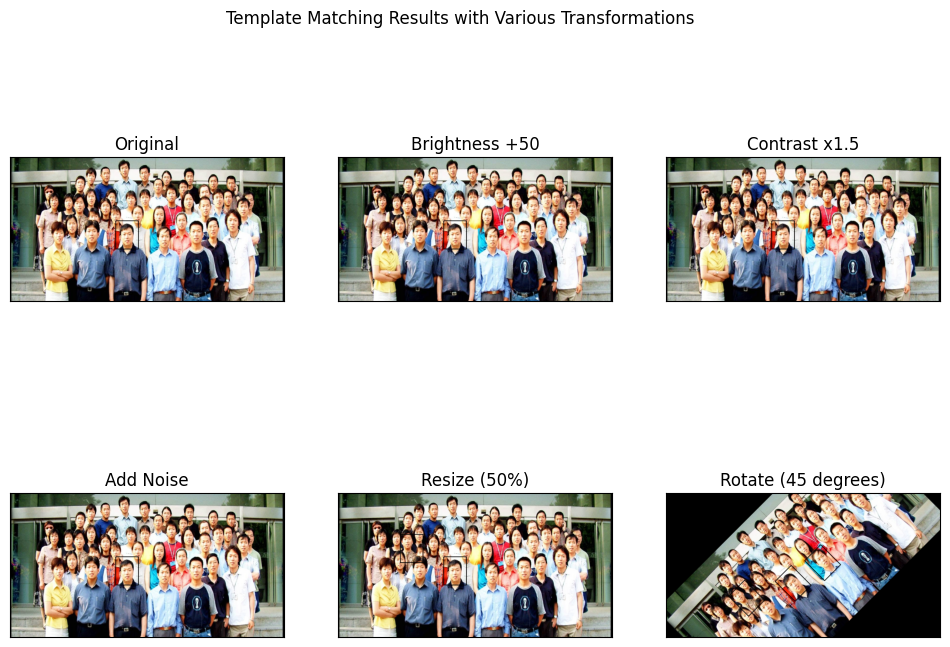

In [42]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# Load the main image in grayscale
colored_img = cv.imread('download.jpg')
colored_img = cv.cvtColor(colored_img, cv.COLOR_BGR2RGB)
img = cv.imread('download.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img2 = img.copy()

# Load the template image in grayscale
template = cv.imread('download (2).jpg', cv.IMREAD_GRAYSCALE)
assert template is not None, "file could not be read, check with os.path.exists()"
w, h = template.shape[::-1]


# Define a function to change brightness and contrast
def adjust_brightness_contrast(image, brightness=0, contrast=1):
    return cv.convertScaleAbs(image, alpha=contrast, beta=brightness)

# Define a function to add noise
def add_noise(image, noise_factor=0.1):
    noise = np.random.normal(0, noise_factor, image.shape).astype(np.uint8)
    noisy_image = cv.add(image, noise)
    return noisy_image

# Define a function to resize the image
def resize_image(image, scale_percent):
    width = int(image.shape[1] * scale_percent / 100)
    height = int(image.shape[0] * scale_percent / 100)
    return cv.resize(image, (width, height))

# Define a function to rotate the image
def rotate_image(image, angle):
    center = (image.shape[1] // 2, image.shape[0] // 2)
    matrix = cv.getRotationMatrix2D(center, angle, 1.0)
    return cv.warpAffine(image, matrix, (image.shape[1], image.shape[0]))

# Apply transformations
transformations = {
    "Original": img2,
    "Brightness +50": adjust_brightness_contrast(img2, brightness=50),
    "Contrast x1.5": adjust_brightness_contrast(img2, contrast=1.5),
    "Add Noise": add_noise(img2, noise_factor=25),
    "Resize (50%)": resize_image(img2, scale_percent=50),
    "Rotate (45 degrees)": rotate_image(img2, angle=45)
}

# Choose a method for comparison
method = cv.TM_CCOEFF_NORMED

# Prepare to display results
plt.figure(figsize=(12, 8))

for i, (title, transformed_img) in enumerate(transformations.items()):
    # Apply template Matching
    res = cv.matchTemplate(transformed_img, template, method)
    if (title == "Rotate (45 degrees)"):
        rotate_image(res, angle=45)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # Determine the top left corner for the rectangle
    top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Draw a rectangle around the matched region
    cv.rectangle(colored_img, top_left, bottom_right, 0, 2)

    if (title == "Rotate (45 degrees)"):
        colored_img = rotate_image(colored_img, angle=45)
    # Display the matching result
    plt.subplot(2, 3, i + 1)
    
    plt.imshow(colored_img, cmap='gray')
    
    plt.title(title)
    plt.xticks([]), plt.yticks([])

plt.suptitle('Template Matching Results with Various Transformations')
plt.show()